<a href="https://colab.research.google.com/github/peakodev/data_science/blob/main/home_02/Hw2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Частина третя: Аналіз датасет c Kaggle.com

In [42]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv('bestsellers with categories.csv')
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

In [44]:
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


*   Про скільки книг зберігає дані датасет?

In [45]:
df.shape

(550, 7)

*   **Відповідь**: 550

# Первинне дослідження даних

*   Чи є в якихось змінних пропуски? (Так / ні)

In [46]:
df.isna().sum()

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64

*   **Відповідь**: Ні



*   Які є унікальні жанри?

In [47]:
df['genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

*   **Відповідь**: Non Fiction, Fiction


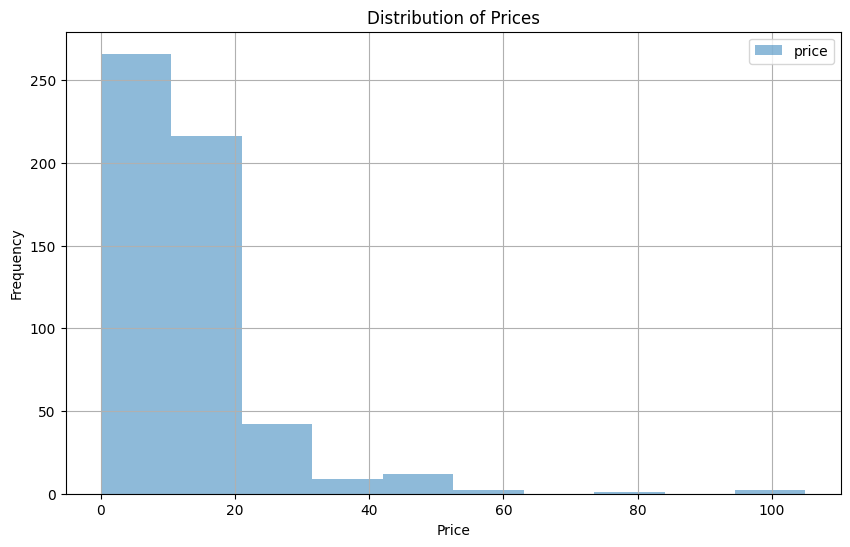

In [48]:
plt.figure(figsize=(10, 6))
df['price'].plot(kind='hist', alpha=0.5, legend=True)
plt.title('Distribution of Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

*   Максимальна ціна?

In [49]:
df['price'].max()

105

*   **Відповідь**: 105



*   Мінімальна ціна?


In [50]:
df['price'].min()

0

*   **Відповідь**: 0


*   Середня ціна?

In [51]:
df['price'].mean()

13.1

*   **Відповідь**: 13.1


*   Медіанна ціна?

In [52]:
df['price'].median()

11.0

*   **Відповідь**: 11.0


# Пошук та сортування даних

Який рейтинг у датасеті найвищий?


In [53]:
df['user_rating'].max()

4.9

**Відповідь:** 4.9



Скільки книг мають такий рейтинг?



In [54]:
len(df[df['user_rating'] == df['user_rating'].max()])

52

**Відповідь:** 52

Яка книга має найбільше відгуків?

In [55]:
df[df['reviews'] == df['reviews'].max()].iloc[0]['name']

'Where the Crawdads Sing'

**Відповідь:** Where the Crawdads Sing

З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)

In [56]:
df.loc[df[df['year'] == 2015]['price'].idxmax(), 'name']

'Publication Manual of the American Psychological Association, 6th Edition'

**Відповідь:** Publication Manual of the American Psychological Association, 6th Edition

Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)?

In [57]:
df[(df['genre'] == 'Fiction') & (df['year'] == 2010)].shape[0]

20

**Відповідь:** 20

Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)?

In [58]:
len(df[(df['user_rating'] == 4.9) & (df['year'].isin([2010, 2011]))])

1

**Відповідь:** 1

І насамкінець, давайте відсортуємо за зростанням ціни всі книги, які потрапили до рейтингу в 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values).
Яка книга остання у відсортованому списку?

In [59]:
custom_sort = df[(df['year'] == 2015) & (df['price'] < 8)].sort_values(by='price').reset_index()
custom_sort

,index,name,author,user_rating,reviews,price,year,genre
0,507,To Kill a Mockingbird,Harper Lee,4.8,26234,0,2015,Fiction
1,210,Laugh-Out-Loud Jokes for Kids,Rob Elliott,4.6,6990,4,2015,Non Fiction
2,206,Knock-Knock Jokes for Kids,Rob Elliott,4.5,3673,4,2015,Non Fiction
3,111,First 100 Words,Roger Priddy,4.7,17323,4,2015,Non Fiction
4,123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
5,54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
6,63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
7,89,Dover Creative Haven Art Nouveau Animal Design...,Marty Noble,4.6,2134,5,2015,Non Fiction
8,478,The Very Hungry Caterpillar,Eric Carle,4.9,19546,5,2015,Fiction
9,201,Killing Reagan: The Violent Assault That Chang...,Bill O'Reilly,4.6,5235,5,2015,Non Fiction


In [60]:
custom_sort.iloc[-1]['name']

'Old School (Diary of a Wimpy Kid #10)'

**Відповідь:** Old School (Diary of a Wimpy Kid #10

# Агрегування даних та з'єднання таблиць

In [61]:
df.groupby('genre').agg({"price": ["min", "max"]})

price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105

* Максимальна ціна для жанру Fiction: **Відповідь:** 82
* Мінімальна ціна для жанру Fiction: **Відповідь:** 0
* Максимальна ціна для жанру Non Fiction: **Відповідь:** 105
* Мінімальна ціна для жанру Non Fiction: **Відповідь:** 0

In [62]:
authors_books_df = df.groupby('author').agg(count=('author', 'count')).reset_index()
authors_shape = authors_books_df.shape[0]
authors_max_books = authors_books_df.loc[authors_books_df['count'].idxmax()].to_list()

authors_shape, authors_max_books

(248, ['Jeff Kinney', 12])

* Якої розмірності вийшла таблиця? **Відповідь**: 248
* Який автор має найбільше книг? **Відповідь**: Jeff Kinney
* Скільки книг цього автора? **Відповідь**: 12

In [63]:
authors_rate_df = df.groupby('author').agg({"user_rating": "mean"}).reset_index()
authors_rate_df.min().to_list()

['Abraham Verghese', 3.9]

* У якого автора середній рейтинг мінімальний? **Відповідь**: Abraham Verghese
* Який у цього автора середній рейтинг? **Відповідь**: 3.9

* З'єднайте останні два датафрейми так, щоб для кожного автора було видно кількість книг та середній рейтинг (Використовуйте функцію concat з параметром axis=1).
* Збережіть результат у змінну
Відсортуйте датафрейм за зростаючою кількістю книг та зростаючим рейтингом (використовуйте функцію sort_values)

In [64]:
authors_summary_df = pd.concat([
    authors_books_df.sort_values(by='author').reset_index(drop=True),
    authors_rate_df.sort_values(by='author').reset_index(drop=True)['user_rating']
  ], axis=1)
authors_summary_df = authors_summary_df.sort_values(by=['count', 'user_rating']).reset_index(drop=True)

authors_summary_df

,author,count,user_rating
0,Muriel Barbery,1,4.000000
1,Chris Cleave,1,4.100000
2,Ian K. Smith M.D.,1,4.100000
3,Pierre Dukan,1,4.100000
4,Elizabeth Strout,1,4.200000
...,...,...,...
243,American Psychological Association,10,4.500000
244,Suzanne Collins,11,4.663636
245,Gary Chapman,11,4.736364
246,Rick Riordan,11,4.772727


In [65]:
authors_summary_df.loc[0, 'author']

'Muriel Barbery'

Який автор перший у списку? **Відповідь:** Muriel Barbery

# Графіки

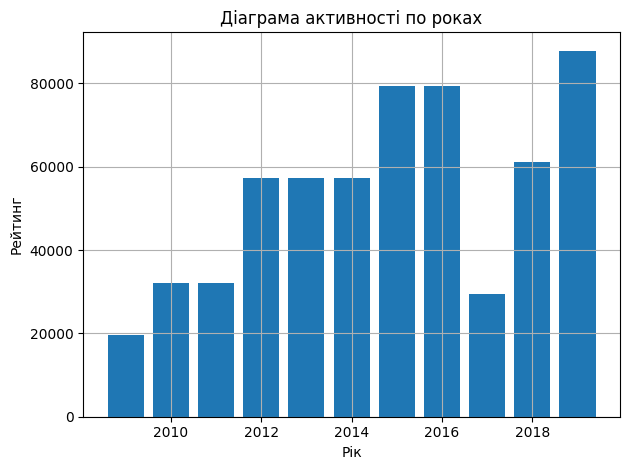

In [66]:
# @title Діаграма активності по роках

plt.bar(df['year'], df['reviews'])
plt.title('Діаграма активності по роках')
plt.xlabel('Рік')
plt.ylabel('Рейтинг')
plt.grid(True)
plt.tight_layout()

plt.show()

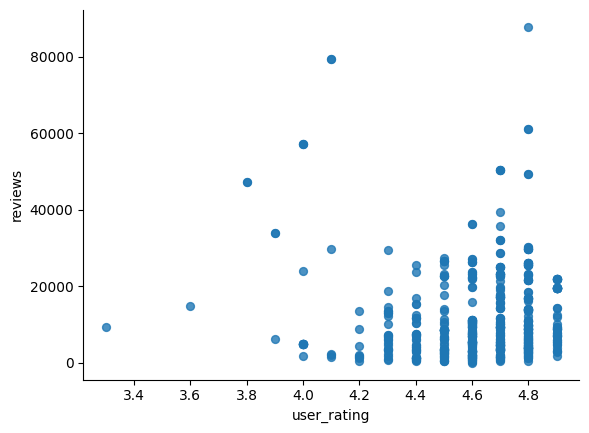

In [67]:
# @title Відношення рейтингів до кількості відгуків

df.plot(kind='scatter', x='user_rating', y='reviews', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

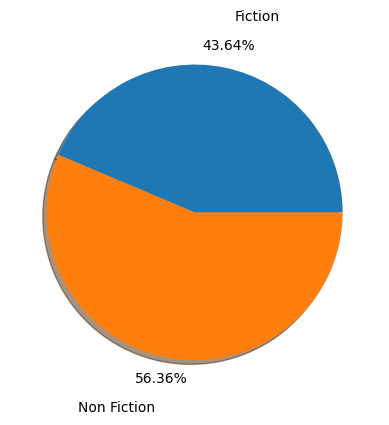

In [87]:
# @title Кількість книг за жанром

df_genre = df.groupby('genre').agg({'genre': 'size'}).rename(columns={'genre': 'count'})
plt.pie(
    df_genre['count'],
    labels=df_genre.index,
    shadow=True,
    autopct="%.2f%%",
    pctdistance=1.15,
    labeldistance=1.35,
)

plt.show()